In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
from DL_modules.models import UNet
from DL_utils.dataset import OurDataset
from DL_utils.utils import EarlyStopper
import scipy.ndimage as ndimage
from sklearn.metrics import precision_recall_fscore_support

# Load Dataset

In [ ]:
from torch.utils.data import random_split

data_folder = r"E:/GISTDA/geo/GeoAnnotation/Result"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

net = UNet(n_class=1).to(device)


criterion = nn.BCEWithLogitsLoss() 
optimizer = optim.Adam(net.parameters(), lr=0.0001)

batch_size = 16
transform_mask = transforms.Compose([
    transforms.Resize((176, 176)), 
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])
transform_image = transforms.Compose([
    transforms.Resize((176, 176)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

full_dataset = OurDataset(data_dir=data_folder,data_mode = "theos",transform_image=transform_image,transform_mask=transform_mask )

# Figure out the 80/10/10 math
total_images = len(full_dataset)
train_count = int(0.8 * total_images)
valid_count = int(0.1 * total_images)
test_count = total_images - train_count - valid_count

print(f"Total valid image/mask pairs found: {total_images}")
print(f"Training on: {train_count} images | Validating on: {valid_count} images | Testing on: {test_count} images")

# Shuffle and split! 
trainset, validset, testset = random_split(
    full_dataset, 
    [train_count, valid_count, test_count],
    generator=torch.Generator().manual_seed(42) 
)


trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)
validloader = DataLoader(validset, batch_size=1, shuffle=False, num_workers=0)
testloader = DataLoader(testset, batch_size=1, shuffle=False, num_workers=0)

Using device: cuda
Total valid image/mask pairs found: 1600
Training on: 1280 images | Validating on: 160 images | Testing on: 160 images


# Training Unet with 1280 grid

In [ ]:
early_stopper = EarlyStopper(patience=5) # If validation loss doesn't improve for 5 consecutive epochs, stop training
train_loss_history = []
valid_loss_history = []
epochs = 50 

for epoch in range(epochs):
    print(f"Epoch {epoch+1}")
    
    # --- TRAINING ---
    net.train()
    epoch_train_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    
    avg_train_loss = epoch_train_loss / len(trainloader)
    train_loss_history.append(avg_train_loss)

    # --- VALIDATION ---
    net.eval()
    epoch_valid_loss = 0.0
    with torch.no_grad():
        for inputs, labels in validloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            epoch_valid_loss += loss.item()
    
    avg_valid_loss = epoch_valid_loss / len(validloader)
    valid_loss_history.append(avg_valid_loss)
    
    print(f"Train Loss: {avg_train_loss:.4f} | Valid Loss: {avg_valid_loss:.4f}")

    can_save, continue_training = early_stopper.check(epoch, avg_valid_loss)
    
    print(f'Epoch [{epoch + 1}/{epochs}] - Train Loss: {avg_train_loss:.4f} | Validation Loss: {avg_valid_loss:.4f}') 
    
    if can_save:
        print("Model saved to 'model-%0000d.pth'" % epoch)
        torch.save(net.state_dict(), 'model-%0000d.pth' % epoch)

    if not continue_training:    
        break  

print('Finished Training')

Epoch 1
Train Loss: 0.6630 | Valid Loss: 0.6357
Epoch [1/50] - Train Loss: 0.6630 | Validation Loss: 0.6357
Model saved to 'model-0.pth'
Epoch 2
Train Loss: 0.6423 | Valid Loss: 0.6210
Epoch [2/50] - Train Loss: 0.6423 | Validation Loss: 0.6210
Model saved to 'model-1.pth'
Epoch 3
Train Loss: 0.6194 | Valid Loss: 0.6003
Epoch [3/50] - Train Loss: 0.6194 | Validation Loss: 0.6003
Model saved to 'model-2.pth'
Epoch 4
Train Loss: 0.5929 | Valid Loss: 0.5509
Epoch [4/50] - Train Loss: 0.5929 | Validation Loss: 0.5509
Model saved to 'model-3.pth'
Epoch 5
Train Loss: 0.5695 | Valid Loss: 0.5376
Epoch [5/50] - Train Loss: 0.5695 | Validation Loss: 0.5376
Model saved to 'model-4.pth'
Epoch 6
Train Loss: 0.5257 | Valid Loss: 0.4901
Epoch [6/50] - Train Loss: 0.5257 | Validation Loss: 0.4901
Model saved to 'model-5.pth'
Epoch 7
Train Loss: 0.5052 | Valid Loss: 0.4909
Epoch [7/50] - Train Loss: 0.5052 | Validation Loss: 0.4909
Epoch 8
Train Loss: 0.4983 | Valid Loss: 0.4560
Epoch [8/50] - Train L

# Visual Comparison

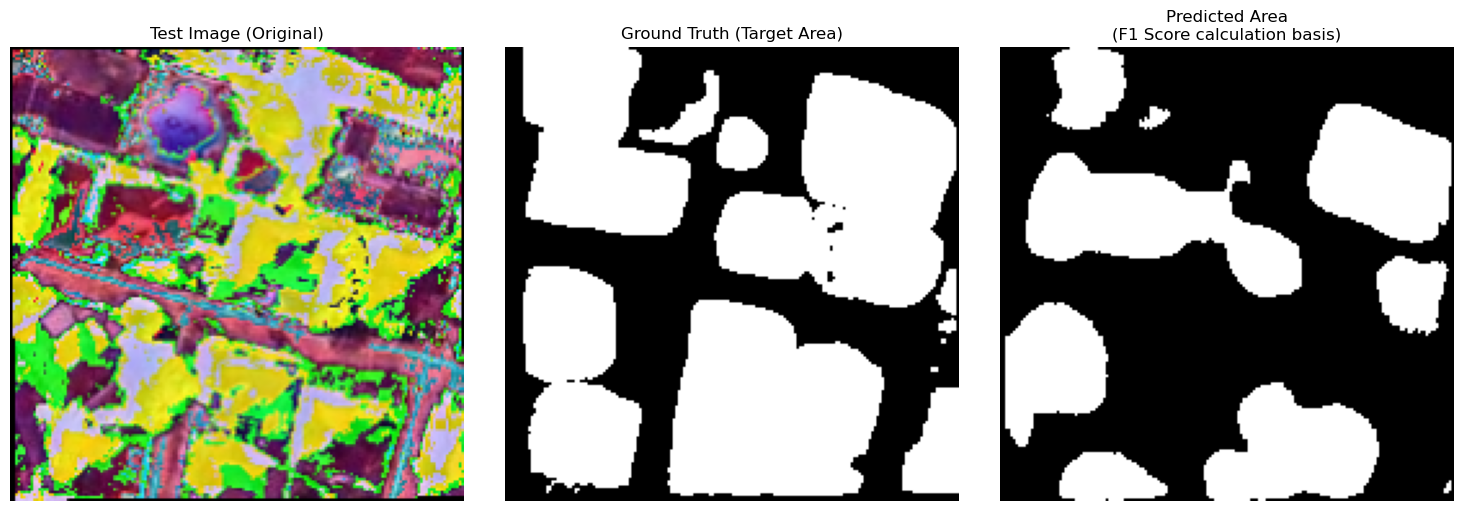

In [9]:
import matplotlib.pyplot as plt

# 1. เข้าสู่โหมด Evaluate และใช้ Test Set (10% ที่แบ่งไว้)
net.eval()
test_image_sample = None
test_mask_sample = None
test_pred_sample = None

with torch.no_grad():
    # ดึงตัวอย่างแรกจาก testloader
    for data in testloader:
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = net(inputs)
        pred_mask = (torch.sigmoid(outputs) > 0.5).float()
        
        # เก็บตัวอย่างไว้ 1 อันเพื่อแสดงผล
        test_image_sample = inputs[0].cpu().numpy()
        test_mask_sample = labels[0].cpu().numpy()
        test_pred_sample = pred_mask[0].cpu().numpy()
        break # เอาแค่ตัวอย่างเดียวแล้วหยุด

# 2. เตรียมข้อมูลสำหรับ Plot (แปลงมิติจาก CHW เป็น HWC)
# ภาพต้นฉบับ: แก้ Normalize 0.5 กลับมาเป็นช่วง 0-1
img_to_show = np.transpose(test_image_sample, (1, 2, 0))
img_to_show = (img_to_show * 0.5) + 0.5
img_to_show = np.clip(img_to_show, 0, 1)

# Mask: บีบมิติ Channel ออกให้เหลือแค่ H, W
gt_to_show = test_mask_sample.squeeze()
pred_to_show = test_pred_sample.squeeze()

# 3. แสดงผลเปรียบเทียบพื้นที่ (Area-based comparison)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_to_show)
plt.title("Test Image (Original)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gt_to_show, cmap='gray')
plt.title("Ground Truth (Target Area)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(pred_to_show, cmap='gray')
plt.title(f"Predicted Area\n(F1 Score calculation basis)")
plt.axis('off')

plt.tight_layout()
plt.show()

# Evaluate Accuracy (F1-Score)

In [ ]:
all_bf1_scores = []
input_image_list = []
input_mask_list = []
pred_mask_list = []
valid_loss = 0.0
validloader = DataLoader(validset, batch_size=1, shuffle=False, num_workers=0)
with torch.no_grad(): # Crucial: prevents GPU memory crash during validation
    for data in validloader:
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)
        input_image_list.append(inputs.cpu().numpy())
        input_mask_list.append(labels.cpu().numpy())
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        valid_loss += loss.item()
        pred_mask = torch.sigmoid(outputs) > 0.5 # ทำเป็น Binary
        pred_mask_list.append(pred_mask.cpu().numpy())
        y_true = labels.squeeze().cpu().numpy()
        y_pred = pred_mask.squeeze().cpu().numpy()
        precision, recall, f1, sup = precision_recall_fscore_support(y_true, y_pred, average='macro',zero_division=0)
        all_bf1_scores.append(f1)

avg_bf1 = sum(all_bf1_scores)/(len(all_bf1_scores))
avg_valid_loss = valid_loss / len(validloader)
valid_loss_history.append(avg_valid_loss)

    
    # Print a clean summary at the end of every single epoch
print("Average F1 Score: " + str(avg_bf1))
print("Average Validation Loss: " + str(avg_valid_loss))

0.5229657692212548
0.3902881077723578


# Plot Bar Chart

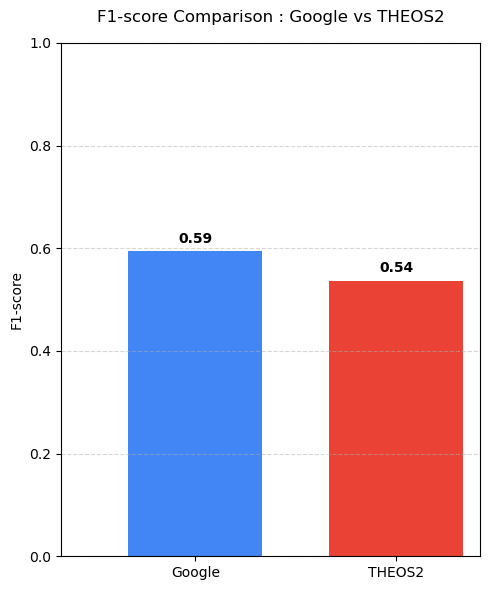

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
sources = ['Google', 'THEOS2']
f1_scores = [0.5949230291628826, 0.5370853492544277]

x_positions = [0, 0.6] 

plt.figure(figsize=(5, 6))
colors = ['#4285F4', '#EA4335']

bars = plt.bar(x_positions, f1_scores, color=colors, width=0.4)


plt.title('F1-score Comparison : Google vs THEOS2', fontsize=12, pad=15)
plt.ylabel('F1-score')
plt.ylim(0, 1.0)

plt.xticks(x_positions, sources) 

plt.grid(axis='y', linestyle='--', alpha=0.5)

# เพิ่มตัวเลขบนหัวแท่ง
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ปรับขอบซ้ายขวาให้แคบลงเพื่อไม่ให้มีพื้นที่ว่างเหลือเยอะเกินไป
plt.xlim(-0.4, 0.85) 

plt.tight_layout()
plt.show()